In [1]:
# If needed
!pip install pandas scikit-learn nltk matplotlib seaborn

import pandas as pd
import numpy as np
import nltk
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn import tree

import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
# Load dataset
df = pd.read_csv("schedule_2025_current_march_25.csv")

# Preview
df.head()

,Date,Conference,Game_Notes,Away_Team,Away_Team_Link,Away_Score,Home_Team,Home_Team_Link,Home_Score,OT,Box_Link,Metrics_Link,Day,Game_ID
0,2024-10-04,Non-Conference,NaN,Michigan State,/reports/team/Michigan-State/32,2.0,Lake Superior,/reports/team/Lake-Superior/24,1.0,ot,/box/final/20241004/msu/lss/,/box/metrics.php?gd=100540,Friday,2024-10-04_Lake Superior_Michigan State
1,2024-10-04,Non-Conference,NaN,Minnesota State,/reports/team/Minnesota-State/35,5.0,Michigan,/reports/team/Michigan/31,2.0,NaN,/box/final/20241004/mns/mic/,/box/metrics.php?gd=100317,Friday,2024-10-04_Michigan_Minnesota State
2,2024-10-04,Non-Conference,NaN,Arizona State,/reports/team/Arizona-State/61,8.0,Air Force,/reports/team/Air-Force/1,1.0,NaN,/box/final/20241004/asu/afa/,/box/metrics.php?gd=99879,Friday,2024-10-04_Air Force_Arizona State
3,2024-10-04,Non-Conference,NaN,Bowling Green,/reports/team/Bowling-Green/11,2.0,Mercyhurst,/reports/team/Mercyhurst/28,1.0,NaN,/box/final/20241004/bgs/mrc/,/box/metrics.php?gd=100386,Friday,2024-10-04_Mercyhurst_Bowling Green
4,2024-10-04,Non-Conference,NaN,Colgate,/reports/team/Colgate/15,2.0,Connecticut,/reports/team/Connecticut/17,4.0,NaN,/box/final/20241004/clg/con/,/box/metrics.php?gd=100832,Friday,2024-10-04_Connecticut_Colgate


In [3]:
# Load dataset
df = pd.read_csv("schedule_2025_current_march_25.csv")

# Preview
df.head()

,Date,Conference,Game_Notes,Away_Team,Away_Team_Link,Away_Score,Home_Team,Home_Team_Link,Home_Score,OT,Box_Link,Metrics_Link,Day,Game_ID
0,2024-10-04,Non-Conference,NaN,Michigan State,/reports/team/Michigan-State/32,2.0,Lake Superior,/reports/team/Lake-Superior/24,1.0,ot,/box/final/20241004/msu/lss/,/box/metrics.php?gd=100540,Friday,2024-10-04_Lake Superior_Michigan State
1,2024-10-04,Non-Conference,NaN,Minnesota State,/reports/team/Minnesota-State/35,5.0,Michigan,/reports/team/Michigan/31,2.0,NaN,/box/final/20241004/mns/mic/,/box/metrics.php?gd=100317,Friday,2024-10-04_Michigan_Minnesota State
2,2024-10-04,Non-Conference,NaN,Arizona State,/reports/team/Arizona-State/61,8.0,Air Force,/reports/team/Air-Force/1,1.0,NaN,/box/final/20241004/asu/afa/,/box/metrics.php?gd=99879,Friday,2024-10-04_Air Force_Arizona State
3,2024-10-04,Non-Conference,NaN,Bowling Green,/reports/team/Bowling-Green/11,2.0,Mercyhurst,/reports/team/Mercyhurst/28,1.0,NaN,/box/final/20241004/bgs/mrc/,/box/metrics.php?gd=100386,Friday,2024-10-04_Mercyhurst_Bowling Green
4,2024-10-04,Non-Conference,NaN,Colgate,/reports/team/Colgate/15,2.0,Connecticut,/reports/team/Connecticut/17,4.0,NaN,/box/final/20241004/clg/con/,/box/metrics.php?gd=100832,Friday,2024-10-04_Connecticut_Colgate


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1230 entries, 0 to 1229
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            1230 non-null   str    
 1   Conference      1230 non-null   str    
 2   Game_Notes      107 non-null    str    
 3   Away_Team       1230 non-null   str    
 4   Away_Team_Link  1178 non-null   str    
 5   Away_Score      1215 non-null   float64
 6   Home_Team       1230 non-null   str    
 7   Home_Team_Link  1219 non-null   str    
 8   Home_Score      1215 non-null   float64
 9   OT              261 non-null    str    
 10  Box_Link        1230 non-null   str    
 11  Metrics_Link    1167 non-null   str    
 12  Day             1230 non-null   str    
 13  Game_ID         1230 non-null   str    
dtypes: float64(2), str(12)
memory usage: 364.0 KB


In [6]:
print(df.columns.tolist())

['Date', 'Conference', 'Game_Notes', 'Away_Team', 'Away_Team_Link', 'Away_Score', 'Home_Team', 'Home_Team_Link', 'Home_Score', 'OT', 'Box_Link', 'Metrics_Link', 'Day', 'Game_ID']


In [7]:
df.columns

Index(['Date', 'Conference', 'Game_Notes', 'Away_Team', 'Away_Team_Link',
       'Away_Score', 'Home_Team', 'Home_Team_Link', 'Home_Score', 'OT',
       'Box_Link', 'Metrics_Link', 'Day', 'Game_ID'],
      dtype='str')

In [9]:
df.head()

,Date,Conference,Game_Notes,Away_Team,Away_Team_Link,Away_Score,Home_Team,Home_Team_Link,Home_Score,OT,Box_Link,Metrics_Link,Day,Game_ID
0,2024-10-04,Non-Conference,NaN,Michigan State,/reports/team/Michigan-State/32,2.0,Lake Superior,/reports/team/Lake-Superior/24,1.0,ot,/box/final/20241004/msu/lss/,/box/metrics.php?gd=100540,Friday,2024-10-04_Lake Superior_Michigan State
1,2024-10-04,Non-Conference,NaN,Minnesota State,/reports/team/Minnesota-State/35,5.0,Michigan,/reports/team/Michigan/31,2.0,NaN,/box/final/20241004/mns/mic/,/box/metrics.php?gd=100317,Friday,2024-10-04_Michigan_Minnesota State
2,2024-10-04,Non-Conference,NaN,Arizona State,/reports/team/Arizona-State/61,8.0,Air Force,/reports/team/Air-Force/1,1.0,NaN,/box/final/20241004/asu/afa/,/box/metrics.php?gd=99879,Friday,2024-10-04_Air Force_Arizona State
3,2024-10-04,Non-Conference,NaN,Bowling Green,/reports/team/Bowling-Green/11,2.0,Mercyhurst,/reports/team/Mercyhurst/28,1.0,NaN,/box/final/20241004/bgs/mrc/,/box/metrics.php?gd=100386,Friday,2024-10-04_Mercyhurst_Bowling Green
4,2024-10-04,Non-Conference,NaN,Colgate,/reports/team/Colgate/15,2.0,Connecticut,/reports/team/Connecticut/17,4.0,NaN,/box/final/20241004/clg/con/,/box/metrics.php?gd=100832,Friday,2024-10-04_Connecticut_Colgate


In [10]:
print(list(df.columns))

['Date', 'Conference', 'Game_Notes', 'Away_Team', 'Away_Team_Link', 'Away_Score', 'Home_Team', 'Home_Team_Link', 'Home_Score', 'OT', 'Box_Link', 'Metrics_Link', 'Day', 'Game_ID']


In [11]:
df.columns = df.columns.str.strip()

In [13]:
print(df.columns)

Index(['Date', 'Conference', 'Game_Notes', 'Away_Team', 'Away_Team_Link',
       'Away_Score', 'Home_Team', 'Home_Team_Link', 'Home_Score', 'OT',
       'Box_Link', 'Metrics_Link', 'Day', 'Game_ID'],
      dtype='str')


In [16]:
# Import required libraries
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Example dataset (replace this with your real dataset)
data = {
    "text": [
        "This movie was amazing and I loved it",
        "The film was terrible and boring",
        "Fantastic acting and great story",
        "Worst movie I have ever seen",
        "I really enjoyed this film"
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

# Define the text column
X_text = df["text"]

# Initialize TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=3000)

# Convert text into TF-IDF feature matrix
X = vectorizer.fit_transform(X_text)

# Convert result to a readable dataframe
X_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

# Print results
print(X_df)

     acting   amazing       and    boring   enjoyed      ever  fantastic  \
0  0.000000  0.430281  0.288164  0.000000  0.000000  0.000000   0.000000   
1  0.000000  0.000000  0.307274  0.458815  0.000000  0.000000   0.000000   
2  0.474125  0.000000  0.317527  0.000000  0.000000  0.000000   0.474125   
3  0.000000  0.000000  0.000000  0.000000  0.000000  0.463693   0.000000   
4  0.000000  0.000000  0.000000  0.000000  0.550329  0.000000   0.000000   

       film     great      have  ...     loved     movie    really      seen  \
0  0.000000  0.000000  0.000000  ...  0.430281  0.347148  0.000000  0.000000   
1  0.370169  0.000000  0.000000  ...  0.000000  0.000000  0.000000  0.000000   
2  0.000000  0.474125  0.000000  ...  0.000000  0.000000  0.000000  0.000000   
3  0.000000  0.000000  0.463693  ...  0.000000  0.374105  0.000000  0.463693   
4  0.444002  0.000000  0.000000  ...  0.000000  0.000000  0.550329  0.000000   

      story  terrible       the      this       was     worst 

In [19]:
df.head()
df.columns

Index(['text'], dtype='str')

In [24]:
df.head()
df.columns

Index(['text'], dtype='str')

In [30]:
print(df.columns)

Index(['Date', 'Conference', 'Game_Notes', 'Away_Team', 'Away_Team_Link',
       'Away_Score', 'Home_Team', 'Home_Team_Link', 'Home_Score', 'OT',
       'Box_Link', 'Metrics_Link', 'Day', 'Game_ID'],
      dtype='str')


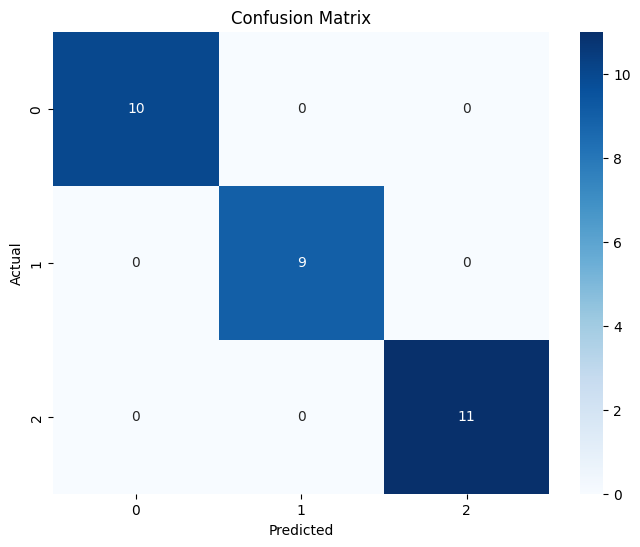

In [35]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
data = load_iris()
X = data.data
y = data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [37]:
print(example_vector.shape)
print(model.n_features_in_)

(1, 21)
4
